## Populations of the dressed states
Imabalance between + and - populations due to THz cavity coupling.
In the case of no coupling we'd observe both populations, equal at 1/2. The Thz cavity favours - state
We fix $\Delta_q=0$ at all times.

1. Draw the imbalance graph

2. Fit to a Lorentzian and extract FWMH $\rightarrow$ we expect to see $width = \Gamma_{Purcell} = 4g^2/\kappa$ with $g=2\sin\theta\cos\theta\cdot\chi$

3. Recreate the imabalance graph with peak height instead of populations.

### notes:
- I have surpressed the "optical" cavity used as a sensor, as the spectrum is not required in this calculation, with the aim to speed it up.
- I assumed the known result $\braket{+|\rho_{SS}|+} = \braket{-|\rho_{SS}|-} = \frac{1}{2}$ for a single qubit, instead of calculating explicitely.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

Parameters

In [8]:
kappa_b = 1 #decay en la cav de THz
gamma = 1e-4 * kappa_b # decay en el qubit

chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Nb = 3         # segunda cavidad

w_THz_list = np.linspace(0, 400, 91)

Operators

In [9]:
sx = tensor(sigmax(), qeye(Nb))
sz = tensor(sigmaz(), qeye(Nb))
sm = tensor(sigmam(), qeye(Nb))

b = tensor(qeye(2), destroy(Nb))
b_dag = b.dag()

# Disipadores
D_with = [
    np.sqrt(gamma) * sm,
    np.sqrt(kappa_b) * b
]

print('hola')

hola


## 1. Population imabalance graph
1. Definition of $\ket{\pm}$ as the eigenstates of the  single qubit hamiltonian: $H_q = \frac{\Omega}{2}\sigma_x + \Delta_q\sigma_z$ (where $\Delta_q= 0$ in this case)
2. Obtention of the density matrix @ steady state
3. Calculation of the expectation value of the dressed states projectors

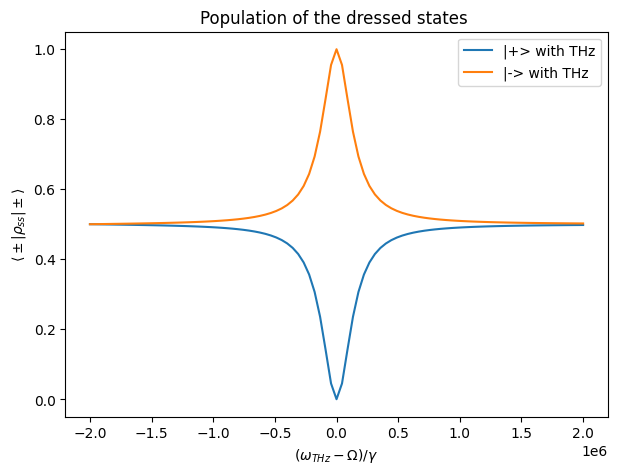

In [10]:
# vectors where we store the population @ each w_b
pops_plus = []
pops_minus = []

x_axis = w_THz_list - Omega* np.ones(len(w_THz_list))

for w_b in w_THz_list:

    Delta_q = 0
    H_qubit = (Omega/2)*sigmax() + Delta_q*sigmaz()
    eigvals, eigstates = H_qubit.eigenstates()

    plus_state = eigstates[1]  # mayor energía
    minus_state = eigstates[0] #menor energía

    # extender al espacio total
    plus = tensor(eigstates[1], qeye(Nb))
    P_plus = plus * plus.dag()

    minus = tensor(eigstates[0], qeye(Nb))
    P_minus = minus * minus.dag()

    H = (Omega/2)*sx + Delta_q * sz + w_b * b_dag * b + chi * (sz + 1) * (b + b_dag)

    rho_ss_with = steadystate(H, D_with)
    pop_plus= expect(P_plus, rho_ss_with)
    pop_minus = expect(P_minus, rho_ss_with)

    pops_minus.append(pop_minus)
    pops_plus.append(pop_plus)

# =========================
# Gráfica
# =========================
plt.figure(figsize=(7,5))

plt.plot(x_axis/gamma, pops_plus, label="|+> with THz")
plt.plot(x_axis/gamma, pops_minus, label="|-> with THz")

plt.xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
plt.ylabel(r"$\langle \pm | \rho_{ss} | \pm \rangle$")
plt.title("Population of the dressed states ")

plt.legend()


plt.show()

## 2. Lorentzian fit

$$ L(x)  = A\frac{a^2}{(x-x_0)^2+a^2}+C$$
$A$ = amplitud
$x_0$ = center
$a$ = FMWHM /2 esto es lo que queremos, ¿no?

- Width $\sim \Gamma_{Purcell}=\frac{4\chi_{eff}^2}{\gamma}$ with $\chi_{eff} = 2\sin\theta\cos\theta\chi$.
And in our case, with $\Delta_q = 0$ we find $\theta=\frac{\pi}{4}\rightarrow\chi_{eff}=\chi$ 


In [11]:
# función lorentziana
def lorentzian(x, A, x0, a, C):
    return A * (a**2 / ((x - x0)**2 + a**2)) + C

-200.0
200.0
Centro x0 = 0.0042444911353735106
HWHM (half width at half maximum) a = 0.001416698996750805
FWHM (full width at half maximum) 2*a = 28.3339799350161
Gamma = 0.04000000000000001


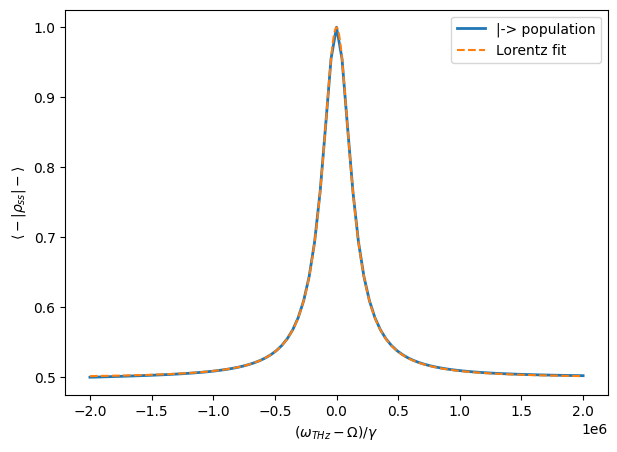

In [12]:
# datos
xdata = x_axis   
print(xdata[0])
print(xdata[-1])
ydata = np.array(pops_minus)
# estimaciones iniciales (muy importantes)
A0 = max(ydata)
x0_0 = 0
a =0.5
C0 = 0.5

p0 = [A0, x0_0, a, C0]

# ajuste
params, cov = curve_fit(lorentzian, xdata, ydata, p0=p0)

A_fit, x0_fit, a_fit, C_fit = params

print("Centro x0 =", x0_fit)
print("HWHM (half width at half maximum) a =", a_fit*gamma)
print("FWHM (full width at half maximum) 2*a =", 2*a_fit)

chi_eff=chi
Gamma = 4*chi_eff**2/kappa_b
print("Gamma =", Gamma)


#---------Add our fit to the graph and check
xfit = np.linspace(min(xdata), max(xdata), 500)
yfit = lorentzian(xfit, *params)

plt.figure(figsize=(7,5))
plt.plot(xdata/gamma, pops_minus, lw=2, label="|-> population")
plt.plot(xfit/gamma, yfit, '--', label="Lorentz fit")

plt.xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
plt.ylabel(r"$\langle - | \rho_{ss} | - \rangle$")
plt.legend()
plt.show()

## 3. Replicate the population imbalance graph with the heighf of left Vs right peaks.
For this, we need to cuple to another cavity that works as a sensor, in orden to  extract the spectrum around the estimated peak. 
The peaks take palce at $\omega=\Omega_R$

In [13]:
kappa_a = 1 # decay en el sensor (debe ser pequeño, pero mayor que g)
g = 0.001       # acoplo qubit con el sensor
Na = 2        # truncación de la primera cavidad 


# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Omega_R = 2*np.sqrt(Delta_q**2+(Omega/2)**2)

In [14]:
# eje horizontal (frecuencia espectral) habrá que fijarlos al rededor de los picos
peaks_LEFT = np.zeros(len(w_THz_list))

Delta_q = 0
H0 =  (Omega/2) * sx \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) + Delta_q * sz
# BUCLE PICO IZQUIERDO
for idx, w_b in enumerate(w_THz_list):
    H1 = H0 + w_b * b_plus * b 
    Delta_a_LEFT = np.linspace(-Omega_R-0.25*Omega, -Omega_R+0.25*Omega, 91)
    for Delta_a in Delta_a_LEFT:

        spectrum=[]
        H = H1 + Delta_a * a_plus*a 
        
        rho_SS = steadystate(H, Dissipators)
        pop_SS = expect(a_plus * a, rho_SS)
        spectrum.append(pop_SS)

    spectrum = np.array(spectrum)
    peaks_LEFT[idx] = max(spectrum)


In [15]:
# eje horizontal (frecuencia espectral) habrá que fijarlos al rededor de los picos
peaks_RIGHT = np.zeros(len(w_THz_list))

Delta_q = 0
H0 =  (Omega/2) * sx \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) + Delta_q * sz
# BUCLE PICO DERECHO
for idx, w_b in enumerate(w_THz_list):
    H1 = H0 + w_b * b_plus * b 
    Delta_a_RIGHT = np.linspace(Omega_R-0.2*Omega, Omega_R+0.2*Omega, 91)
    for Delta_a in Delta_a_RIGHT:

        spectrum=[]
        H = H1 + Delta_a * a_plus*a 
        
        rho_SS = steadystate(H, Dissipators)
        pop_SS = expect(a_plus * a, rho_SS)
        spectrum.append(pop_SS)

    spectrum = np.array(spectrum)
    peaks_RIGHT[idx] = max(spectrum)

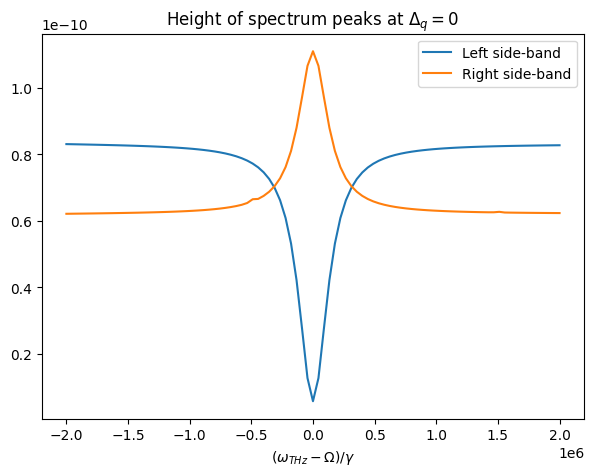

In [16]:
# =========================
# Gráfica
# =========================
fig_peaks, ax = plt.subplots(figsize=(7,5))
ax.plot(x_axis/gamma, peaks_RIGHT, label="Left side-band")
ax.plot(x_axis/gamma, peaks_LEFT, label="Right side-band")

ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_title(r"Height of spectrum peaks at $\Delta_q = 0$")

plt.legend()
plt.show()

Normalizamos en área la gráfica de las poblaciones de $\rho_-$ y del espectro en el pico izquierdo para tratar de establecer una comparación directa

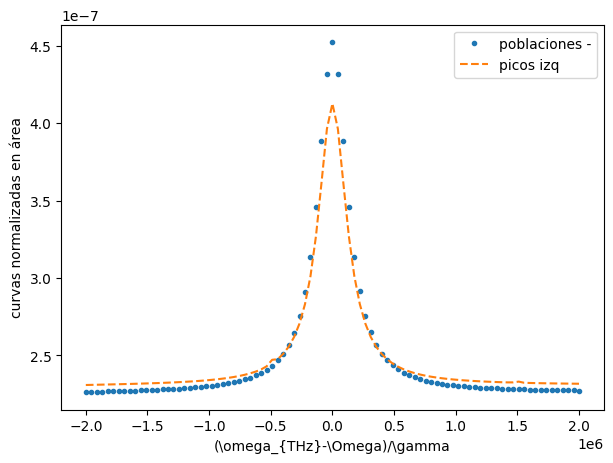

In [17]:
norm_pop_minus = pops_minus/(np.trapezoid(pops_minus, x_axis/gamma))
norm_peaks_left = peaks_LEFT/(np.trapezoid(peaks_LEFT, x_axis/gamma))

plt.figure(figsize=(7,5))
plt.plot(x_axis/gamma, norm_pop_minus, '.', label=r'poblaciones -')
plt.plot(x_axis/gamma, norm_peaks_left,'--', label=r'picos izq')
plt.xlabel(r'(\omega_{THz}-\Omega)/\gamma')
plt.ylabel('curvas normalizadas en área')
plt.legend()

Pendiente izquierda: 10209319564.051376
Pendiente derecha: 6453969057.094586


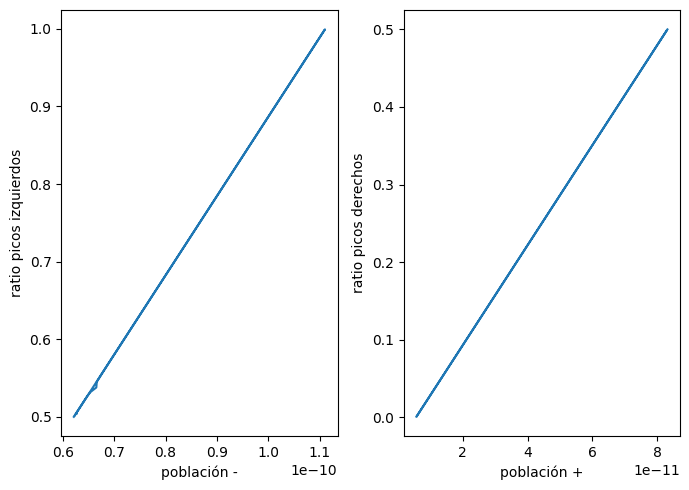

In [18]:
# ajuste de la recta 
m_left, b_left = np.polyfit(peaks_LEFT, pops_minus, 1)
m_right, b_right = np.polyfit(peaks_RIGHT, pops_plus, 1)

print("Pendiente izquierda:", m_left)
print("Pendiente derecha:", m_right)


fig1, ax1 = plt.subplots(1,2, figsize=(7,5))

ax1[0].plot(peaks_LEFT, pops_minus)
ax1[0].set_xlabel('población -')
ax1[0].set_ylabel('ratio picos izquierdos')

ax1[1].plot(peaks_RIGHT, pops_plus)
ax1[1].set_xlabel('población +')
ax1[1].set_ylabel('ratio picos derechos')

plt.tight_layout()
plt.show()

### 4. Comparision with analytical results on POPULATION
We have calculated the population of $\ket{+}$ state analytically to obtain:
$$P_+ = \frac{\gamma\cos^4\theta}{\gamma\cos^4\theta + \gamma\sin^4\theta + \Gamma_P}$$
where $\Gamma_P$ is the Purcell factor, given by: $\Gamma_P = \frac{g^2\gamma}{(\omega_b-\Omega)^2+\gamma^2/4}$, with $g=2\chi\cos\theta\sin\theta$.

Now, we plot this analytical curve and compare it to the numerical solution obtained


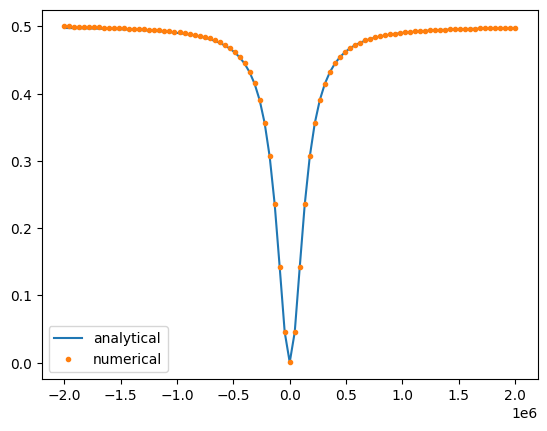

In [19]:
cos = 1/np.sqrt(2)
sin = 1/np.sqrt(2)
g = 2*chi*sin*cos #(in the Delta_q = 0 case)
pump =  gamma*cos**4
decay = gamma * sin**4
P_plus_an = np.zeros(len(w_THz_list))
for idx, w_b in enumerate(w_THz_list):
    Purcell = g**2*kappa_b/((w_b-Omega)**2+kappa_b**2/4)
    P_plus_an[idx] = pump/(pump + (decay + Purcell))

plt.plot(x_axis/gamma, P_plus_an, label = 'analytical')
plt.plot(x_axis/gamma, pops_plus, '.', label  = 'numerical')
plt.legend()




### 5. Comparision with analytical results: SPECTRUM PEAKS.
Ratio in area A_left /A_right (numerical)
- Numerical: fit to a Lorentzian to extract area of the peaks
- Analytical: we expect to see  $\frac{A_{left}}{A_{right}} = \frac{sin^4\theta\langle \xi^\dagger \xi \rangle}{cos^4\theta (1-\langle \xi^\dagger \xi \rangle )}$


In [47]:
def lorentzian(x, A, x0, gamma):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

def mollow_spectrum(x,
                    A0, x0, gamma0,
                    A_L, xL, gammaL,
                    A_R, xR, gammaR,
                    C):
    
    central = lorentzian(x, A0, x0, gamma0)
    left = lorentzian(x, A_L, xL, gammaL)
    right = lorentzian(x, A_R, xR, gammaR)

    return central + left + right + C


A_left = []
A_right = []
A_center = []

# rango completo del Mollow
Delta_a = np.linspace(-1.5*Omega_R, 1.5*Omega_R, 181)

for idx, w_b in enumerate(w_THz_list):

    H1 = H0 + w_b * b_plus * b

    spectrum = []

    for Delta in Delta_a:
        H = H1 + Delta * a_plus * a
        rho_SS = steadystate(H, Dissipators)
        spectrum.append(expect(a_plus * a, rho_SS))

    spectrum = np.array(spectrum)


    # -------------------------
    # guesses iniciales
    # -------------------------

    C0 = np.min(spectrum)

    # pico central
    A0 = np.max(spectrum) - C0
    x0 = Delta_a[np.argmax(spectrum)]
    gamma0 = Omega_R/10

    # picos laterales
    xL = -Omega_R
    xR = Omega_R

    AL = A0/3
    AR = A0/3

    gammaL = Omega_R/10
    gammaR = Omega_R/10


    p0 = [
        A0, x0, gamma0,
        AL, xL, gammaL,
        AR, xR, gammaR,
        C0
    ]


    try:
        popt, pcov = curve_fit(
            mollow_spectrum,
            Delta_a,
            spectrum,
            p0=p0,
            maxfev=50000
        )


        (
        A0_fit, x0_fit, gamma0_fit,
        AL_fit, xL_fit, gammaL_fit,
        AR_fit, xR_fit, gammaR_fit,
        C_fit
        ) = popt


        # áreas de cada Lorentziana
        area_L = np.pi * AL_fit * np.abs(gammaL_fit)
        area_R = np.pi * AR_fit * np.abs(gammaR_fit)
        area_0 = np.pi * A0_fit * np.abs(gamma0_fit)


        A_left.append(area_L)
        A_right.append(area_R)
        A_center.append(area_0)


    except RuntimeError:

        A_left.append(np.nan)
        A_right.append(np.nan)
        A_center.append(np.nan)

/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: divide by zero encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: invalid value encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: divide by zero encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: invalid value encountered in matmul
  cov_x = invR @ invR.T
/Users/carlo

Now, plot the graph of the ratio

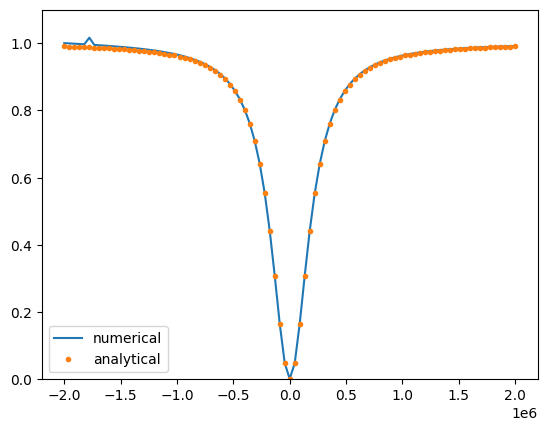

In [56]:
A_left = np.array(A_left)
A_right = np.array(A_right)

areas_num_ratio = A_right/A_left
areas_anan_ratio = sin**4 * P_plus_an/( cos**4 * (1- P_plus_an))

plt.plot(x_axis/gamma, areas_num_ratio, label = 'numerical')
plt.plot(x_axis/gamma, areas_anan_ratio, '.', label = 'analytical')
plt.ylim(0,1.1)
plt.legend()

Caso particular

In [25]:
idx = int(len(w_THz_list)/2)
w_b = w_THz_list[idx]


H1 = H0 + w_b * b_plus * b

spectrum = []

for Delta in Delta_a:
    H = H1 + Delta * a_plus * a
    rho_SS = steadystate(H, Dissipators)
    spectrum.append(expect(a_plus * a, rho_SS))

spectrum = np.array(spectrum)

In [30]:
# -------------------------
# guesses iniciales
# -------------------------

C0 = np.min(spectrum)

# pico central
A0 = np.max(spectrum) - C0
x0 = Delta_a[np.argmax(spectrum)]
gamma0 = Omega_R/10

# picos laterales
xL = -Omega_R
xR = Omega_R

AL = A0/3
AR = A0/3

gammaL = Omega_R/10
gammaR = Omega_R/10


p0 = [
    A0, x0, gamma0,
    AL, xL, gammaL,
    AR, xR, gammaR,
    C0
]

In [31]:
popt, pcov = curve_fit(
    mollow_spectrum,
    Delta_a,
    spectrum,
    p0=p0,
    maxfev=50000
)


(
A0_fit, x0_fit, gamma0_fit,
AL_fit, xL_fit, gammaL_fit,
AR_fit, xR_fit, gammaR_fit,
C_fit
) = popt

/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: divide by zero encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/Users/carlos/.venvs/qutip/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:493: RuntimeWarning: invalid value encountered in matmul
  cov_x = invR @ invR.T


In [ ]:
# áreas de cada Lorentziana
area_L = np.pi * AL_fit * gammaL_fit
area_R = np.pi * AR_fit * gammaR_fit
area_0 = np.pi * A0_fit * gamma0_fit

In [43]:
gammaL_fit

np.float64(-0.505935719571947)